# Lab: Neural Nets
## CMSE 381 - Spring 2022
## April 22, 2022


<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/9/99/Neural_network_example.svg/1200px-Neural_network_example.svg.png" alt="Simple Neural Net" width="200"/>

##ANSWER## 

*Instructor notes:*





In [1]:
# Everyone's favorite standard imports
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import time




# Building your own basic neural network

We're going to try to play with building some simple portions of the neural nets described in class.  

First up, let's try to build the following example we played with in class:
<img src="https://imgur.com/kO6zuGG.jpg" alt="Example Neural Net from Class" width="400"/>

&#9989; **<font color=red>Do this:</font>** Add code where noted below to create an automatic computation of the things we did in class. 

In [2]:
def MyFirstNN(X1,X2,w, beta):
    
    A = []    
    for i in range(3): 
        Ai = np.NaN # <----- your code here
        A.append(Ai)
#     print(A)
    
    A = np.array(A)
    
    Y = np.NaN # <----- your code here

    return Y

 
    
    
w = np.array([(1,2,1),(-1,0,1),(3,-1,-1)])
beta = np.array((-1,2,1,-2))
print('(1,0) should give  1  => ', MyFirstNN(1,0,w,beta))
print('(0,1) should give -1  => ', MyFirstNN(0,1,w,beta))

(1,0) should give  1  =>  nan
(0,1) should give -1  =>  nan


In [62]:
##ANSWER##
def MyFirstNN(X1,X2,w, beta):
    
    X = np.array((X1,X2))
    A = []
    
    for i in range(3): 
        Ai = w[i,0] + np.dot(w[i,1:],X)
        Ai = max(Ai,0)
        A.append(Ai)
#     print(A)
    
    A = np.array(A)
    
    Y = beta[0] + np.dot(beta[1:], A)

    return Y


    
    
    
w = np.array([(1,2,1),(-1,0,1),(3,-1,-1)])
beta = np.array((-1,2,1,-2))
print('(1,0) should give  1  => ', MyFirstNN(1,0,w,beta))
print('(0,1) should give -1  => ', MyFirstNN(0,1,w,beta))


(1,0) should give  1  =>  1
(0,1) should give -1  =>  -1


&#9989; **<font color=red>Do this:</font>**  Play with the following code by changing around your $w$ and $\beta$ matrix values. 
- What sorts of changes occur in the resulting function value outputs?
- We're using the ReLU as our activation function above, which replaces the entry withthe positive value of the entry.  Why am I able to get negative results out of the neural net?


Text(0, 0.5, 'X2')

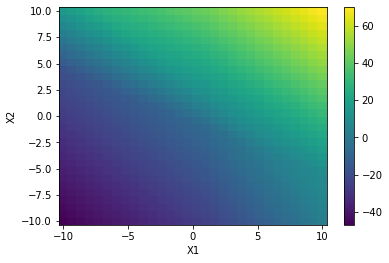

In [70]:
# Your code here #

w = np.array([(1,2,1),(-1,0,1),(3,-1,-1)]) #<----- Mess with these
beta = np.array((-1,2,1,-2))               #<----- These, too

#--- below here plots the output values for many combinations of 
#--- X1,X2

a = np.linspace(-10,10,30)
b = np.linspace(-10,10,30)
x,y = np.meshgrid(a,b)
M = np.zeros((len(a),len(b)))
for i in range(len(a)):
    for j in range(len(a)):
        M[i,j] = MyFirstNN(a[i],b[j],w, beta)
        
plt.pcolormesh(x,y,M,shading = 'auto')
plt.colorbar()
plt.xlabel('X1')
plt.ylabel('X2')

Text(0, 0.5, 'X2')

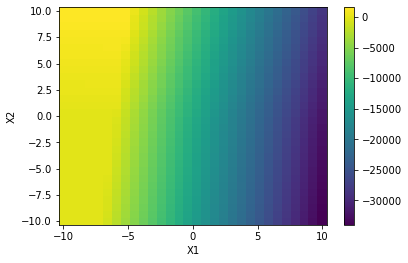

In [71]:
##ANSWER##

w = np.array([(10,20,1),(-1,120,1),(60,-1,10)])
beta = np.array((1,2,1,-200))



#--- below here plots the output values for many combinations of 
#--- X1,X2

a = np.linspace(-10,10,30)
b = np.linspace(-10,10,30)
x,y = np.meshgrid(a,b)
M = np.zeros((len(a),len(b)))
for i in range(len(a)):
    for j in range(len(a)):
        M[i,j] = MyFirstNN(a[i],b[j],w, beta)
        
plt.pcolormesh(x,y,M,shading = 'auto')
plt.colorbar()
plt.xlabel('X1')
plt.ylabel('X2')

&#9989; **<font color=red>Do this:</font>** Write a modified version of your `MyFirstNN` function that uses a sigmoid function instead of ReLu. Draw a 2D heatmap plot like above. What sort of patterns can you get in the resulting output function? 


In [40]:
# Your code here #

In [ ]:
##ANSWER##

def MyFirstNN(X1,X2,w, beta):
    
    X = np.array((X1,X2))
    A = []
    
    for i in range(3): 
        Ai = w[i,0] + np.dot(w[i,1:],X)
        Ai = 1/(1+np.exp(-Ai))
        A.append(Ai)
#     print(A)
    
    A = np.array(A)
    
    Y = beta[0] + np.dot(beta[1:], A)

    return Y


    
    

w = np.array([(1,2,1),(-1,0,1),(3,-1,-1)]) #<----- Original choices 
beta = np.array((-1,2,1,-2))               #<----- of matrices

a = np.linspace(-10,10,30)
b = np.linspace(-10,10,30)
x,y = np.meshgrid(a,b)
M = np.zeros((len(a),len(b)))
for i in range(len(a)):
    for j in range(len(a)):
        M[i,j] = MyFirstNN(a[i],b[j],w, beta)
        
plt.pcolormesh(x,y,M,shading = 'auto')
plt.colorbar()
plt.xlabel('X1')
plt.ylabel('X2')

The functions you have created are what the neural net would predict given a new input data point. 

&#9989; **<font color=red>Q:</font>** For the neural net using  $w$ and $\beta$ from class, and using the sigmoid activation function, what output prediction would you get for an input $(-10,10)$? 

In [82]:
##ANSWER##

w = np.array([(1,2,1),(-1,0,1),(3,-1,-1)]) #<----- Original choices 
beta = np.array((-1,2,1,-2))               #<----- of matrices
# Can just run it through our "trained" neural net
print(MyFirstNN(-10,10,w, beta))

-1.9050248590688805


So of course, if we were actually building this beast, our bigger job would be to find good choices of $w$ and $\beta$ based on our available training data. Let's pretend for the moment I have the following prediction data. 

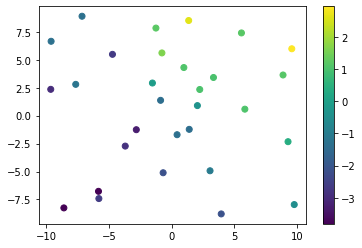

In [116]:
##ANSWER##
# Liz is building fake data, hold on tight.
w = np.array([(1,2,1),(-1,0,1),(3,-1,-1)]) #<----- Original choices 
beta = np.array((-1,2,1,-2))               #<----- of matrices

np.random.seed(0)
X = np.random.random((30,2))*20-10
y = []
for i in range(30):
    y.append(MyFirstNN(X[i,0],X[i,1],w, beta))
y = np.array(y)



ynoise = y + np.random.random(30)*2-1



data = np.concatenate((X,ynoise.reshape(-1,1)),axis = 1)
# print(data)



plt.scatter(X[:,0],X[:,1], c= ynoise)
plt.colorbar()

np.savetxt('DL-toy-data.csv',data)

In [108]:
data = np.loadtxt('DL-toy-data.csv')
X = data[:,:2]
y = data[:,2]

&#9989; **<font color=red>Do this:</font>** Given this particular data set, what is the mean squared error for the neural net using  $w$ and $\beta$ from class, and using the sigmoid activation function?

In [113]:
# Your code here

In [114]:
##ANSWER##

ypredict = []
for i in range(30):
    ypredict.append(MyFirstNN(X[i,0],X[i,1],w, beta))

ypredict = np.array(ypredict)
print(ypredict)


from sklearn.metrics import mean_squared_error

mean_squared_error(y,ypredict)

[ 1.77757187  0.44600319 -0.38762661  1.94153952  0.99644075  1.33219003
  1.99737509 -2.9999046  -1.99824401  1.99824741  1.99318729  1.70360034
 -2.14123248 -1.52642147 -1.82644915 -1.7148781  -0.96028469 -2.20535822
  1.45004923  1.93302017 -2.89817526 -1.94433592  1.87172373 -2.99977975
 -2.97608869 -0.93154137 -0.53394222 -2.99957918 -1.18343422 -2.98900273]


0.382954387472921

We're not going to train the model* ourselves, so let's switch now to the following online tool for training model. 

Open this website in another window: [https://playground.tensorflow.org](https://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=xor&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=4&seed=0.85627&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false)

*Translation: chosing better weights $w$ and $\beta$ to improve this score.


&#9989; **<font color=red>Do this:</font>** 
1. Start by working with a neural network with a single hidden layer on the data set labeled "Exclusive or". The initial setup has random weights chosen so the test loss on the right isn't very good. Hit the play button to watch the model find better and better weights to improve the prediction. 
2. Hover over the neurons on your trained model. What does the colormap shown on the right mean?
2. What does the thickness/color of the edges between features/neurons mean? How does it align with our notation from class?
2. What happens when you train the model using more or less neurons (hidden units) in the layer? What happens if you increase 
3. What happens when you train the same model on the spiral data set? 
4. If your settings are like mine, the sprial data set results are not good. Play with parameters until you can get test loss below 10\% on the spiral data set.

##ANSWER##

One collection of settings I used to get below 10% on spiral, but many others might work. the idea with the last question is just to play with the knobs. 
[My solution to the last question](https://playground.tensorflow.org/#activation=relu&regularization=L1&batchSize=10&dataset=spiral&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=4,4,4&seed=0.27420&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=true&ySquared=true&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false)

# Playing with CNN

Our next job is to get some more intuition for the Convolutional Neural Net architecture. 


<img src="https://www.researchgate.net/profile/Jose-Benitez-Andrades/publication/339447623/figure/fig2/AS:862056077082627@1582541593714/A-vanilla-Convolutional-Neural-Network-CNN-representation.png" alt="Simple Convlutional Neural Net" width="600"/>

Load in the following toy "image" to try out some tools. 

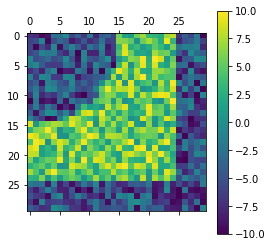

In [153]:
##ANSWER## 

# Liz is making fake data again, watch out! 


np.random.seed(48824)
M = np.random.random((30,30))
M = np.round(10*M, 1)
for i in range(30):
    for j in range(30):
        if i**2 + j**2 < 15**2:
            M[i,j] -= 10

M[25:,:] -=10
M[:25,25:]-=10

plt.matshow(M)
plt.colorbar()

np.savetxt('DL-ToyImage.csv',M)

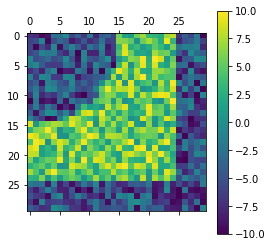

In [154]:
M = np.loadtxt('DL-ToyImage.csv')
plt.matshow(M)
plt.colorbar()

First, we're going to try out convlution on this image. Here's a convolution filter matrix for us to test this onn.

In [145]:
F = np.zeros((5,5))
F[:,:2] = 1
F[:, 3:] = 1
F

array([[1., 1., 0., 1., 1.],
       [1., 1., 0., 1., 1.],
       [1., 1., 0., 1., 1.],
       [1., 1., 0., 1., 1.],
       [1., 1., 0., 1., 1.]])

&#9989; **<font color=red>Do this:</font>** Update this `NewM` matrix so that each entry is the convolution of the input image . 

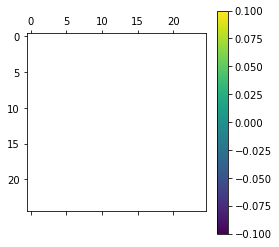

In [158]:
NewM = np.zeros((30-F.shape[0],30-F.shape[0]))
for i in range(NewM.shape[0]):
    for j in range(NewM.shape[1]):
        NewM[i,j] = np.NaN #<----------- you need to fix this
        
plt.matshow(NewM)
plt.colorbar()

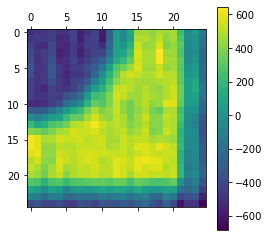

In [159]:
##ANSWER##

NewM = np.zeros((30-F.shape[0],30-F.shape[0]))
for i in range(NewM.shape[0]):
    for j in range(NewM.shape[1]):
        NewM[i,j] = np.sum(np.dot(M[i:i+F.shape[0], j:j+F.shape[1]], F))
plt.matshow(NewM)
plt.colorbar()

&#9989; **<font color=red>Do this:</font>** Here's a different filter. What happens when you convolve the image with this one instead? 

In [160]:
F = np.zeros((5,5))
F[:2,:] = 1
F

array([[1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])

In [ ]:
# Your code here

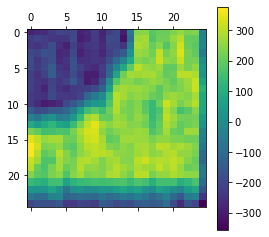

In [163]:
##ANSWER##

NewM = np.zeros((30-5,30-5))
for i in range(30-5):
    for j in range(30-5):
        NewM[i,j] = np.sum(np.dot(M[i:i+5, j:j+5], F))
plt.matshow(NewM)
plt.colorbar()

After our convolution layer, we often build a pooling layer. 

&#9989; **<font color=red>Do this:</font>** Fix up the following code to create a pooled image from your convolved image.

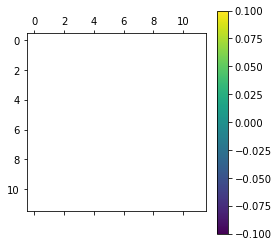

In [165]:
poolM = np.zeros( (NewM.shape[0]//2, NewM.shape[1]//2) )
for i in range(NewM.shape[0]//2):
    for j in range(NewM.shape[0]//2):
        poolM[i,j] = np.NaN #<------------Fix this

plt.matshow(poolM)
plt.colorbar()

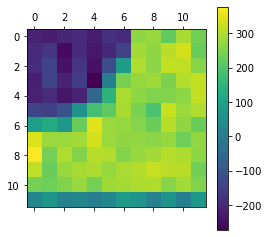

In [166]:
##ANSWER##
poolM = np.zeros( (NewM.shape[0]//2, NewM.shape[1]//2) )
for i in range(NewM.shape[0]//2):
    for j in range(NewM.shape[0]//2):
        poolM[i,j] = np.max(NewM[2*i:2*i+2,2*j:2*j+2])

plt.matshow(poolM)
plt.colorbar()

As with the regular neural nets, trying to train our own CNN is beyond the scope of the class. But we can play with some toys to see how the trained versions work. 

Open the following in another browser tab to answer the questions below: https://poloclub.github.io/cnn-explainer/


&#9989; **<font color=red>Q:</font>** 
1. Read the section below on what each layer of the network does. 
1. What is the 2nd top prediction output for the bell pepper picture?
1. Clicking on the "+" button lets you upload a picture.  What does your face get classified as?

# Lab Survey

To get credit for today's lab, fill out the following survey before the end of class:

https://forms.gle/hX8GT5FJ2fNMeTo1A

Note this is the same link for every lab, so you will fill this out multiple times this semester.



-----
### Congratulations, we're done!
Written by Dr. Liz Munch, Michigan State University

<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.

In [167]:
##ANSWER## 
# This cell gets the name of the current notebook. Needs a sec
# to run before it works

from jupyterinstruct import InstructorNotebook
this_notebook = InstructorNotebook.getname()


##ANSWER## 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [168]:
##ANSWER##
#This cell runs the converter which removes ANSWER fields, renames the notebook and cleans out output fields. 

studentnotebook = InstructorNotebook.makestudent(this_notebook)
InstructorNotebook.validate(studentnotebook)

Myfilename Lab-Ch10-Part3-NN-INSTRUCTOR.ipynb


Lab-Ch10_Part3_NN.ipynb


Validating Notebook ./Lab-Ch10_Part3_NN.ipynb
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..


4